# Visualizing Custom YOLO Data Augmentations
This notebook demonstrates how the custom advanced data augmentations defined in `hyp.yaml` affect the images from our dataset during training. 

### Custom Augmentation Settings:
- **Mosaic (`1.0`):** Combines 4 training images into one, forcing the model to learn to identify objects at different scales and in different contexts.
- **Mixup (`0.15`):** Overlays two images on top of each other, helping the model generalize better to diverse patterns.
- **Copy-Paste (`0.4`):** Copies objects from rare classes (like Truck/Motorbike) and pastes them onto other images, mitigating class imbalance.
- **Degrees (`10.0`):** Applies random small rotations.
- **Scale (`0.5`):** Applies random resizing.
- **Fliplr (`0.5`):** Applies random horizontal flipping.

In [1]:
import os
import yaml
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics.data.dataset import YOLODataset
from ultralytics.cfg import get_cfg, DEFAULT_CFG
from ultralytics.data.augment import MixUp, RandomFlip

# Monkey-patch/wrap MixUp to capture if it gets applied
original_mixup_call = MixUp.__call__
def wrapped_mixup_call(self, labels):
    orig_uniform = random.uniform
    mixup_applied = False
    def mock_uniform(a, b):
        val = orig_uniform(a, b)
        nonlocal mixup_applied
        if val <= self.p:
            mixup_applied = True
        return val
    random.uniform = mock_uniform
    try:
        res = original_mixup_call(self, labels)
    finally:
        random.uniform = orig_uniform
    if mixup_applied:
        res["mixup_applied"] = True
    return res
MixUp.__call__ = wrapped_mixup_call

# Monkey-patch/wrap RandomFlip to capture if horizontal flip gets applied
original_flip_get_params = RandomFlip.get_params
def wrapped_flip_get_params(self, labels):
    params = original_flip_get_params(self, labels)
    if params.get("flip", False):
        direction = params.get("direction", "horizontal")
        labels[f"flip_{direction}_applied"] = True
    return params
RandomFlip.get_params = wrapped_flip_get_params

# 1. Resolve paths dynamically
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if "analyst" in current_dir else current_dir

hyp_path = os.path.join(project_root, "hyp.yaml")
dataset_yaml_path = os.path.join(project_root, "dataset/dataset.yaml")
train_img_path = os.path.join(project_root, "dataset/train/images")

print(f"Project Root resolved to: {project_root}")

Project Root resolved to: /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO


In [2]:
# 2. Load the base configurations and apply hyp.yaml overrides
cfg = get_cfg(DEFAULT_CFG)

with open(hyp_path, "r") as f:
    overrides = yaml.safe_load(f)

for k, v in overrides.items():
    setattr(cfg, k, v)

# Set required training parameter flags for the dataset class
cfg.rect = False
cfg.fraction = 1.0
cfg.single_cls = False
cfg.task = "detect"
cfg.mode = "train"
cfg.imgsz = 640
cfg.cache = False

# Load dataset YAML mapping file
with open(dataset_yaml_path, "r") as f:
    data_dict = yaml.safe_load(f)

print("=== Configured Augmentation Parameters ===")
print(f"  mosaic     : {cfg.mosaic}")
print(f"  mixup      : {cfg.mixup}")
print(f"  copy_paste : {cfg.copy_paste}")
print(f"  degrees    : {cfg.degrees}")
print(f"  scale      : {cfg.scale}")
print(f"  fliplr     : {cfg.fliplr}")

=== Configured Augmentation Parameters ===
  mosaic     : 1.0
  mixup      : 0.15
  copy_paste : 0.4
  degrees    : 10.0
  scale      : 0.5
  fliplr     : 0.5


### Helper Function to Draw Annotated Bounding Boxes
The bounding boxes returned by the dataset are normalized center-based coordinates (`[center_x, center_y, width, height]`). We convert them to absolute pixel coordinates and draw them on the image.

In [3]:
# Color map for classes: motorbike (0), car (1), truck (2), bus (3)
CLASS_COLORS = {
    0: (230, 25, 75),   # Red-ish
    1: (60, 180, 75),   # Green
    2: (245, 130, 48),  # Orange
    3: (0, 130, 200)    # Blue
}
CLASS_NAMES = data_dict["names"]

def draw_annotations(img, bboxes, cls_ids):
    """Draw bounding boxes and class name labels onto the image."""
    h, w, _ = img.shape
    img_draw = img.copy()
    
    for bbox, cls_id in zip(bboxes, cls_ids):
        cls_id = int(cls_id.item())
        color = CLASS_COLORS.get(cls_id, (255, 255, 255))
        label_text = CLASS_NAMES.get(cls_id, f"Class {cls_id}")
        
        # Convert normalized xywh to absolute xyxy
        cx, cy, bw, bh = bbox.tolist()
        x1 = int((cx - bw / 2) * w)
        y1 = int((cy - bh / 2) * h)
        x2 = int((cx + bw / 2) * w)
        y2 = int((cy + bh / 2) * h)
        
        # Draw bounding box
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 2)
        
        # Add text label
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        thickness = 1
        (text_w, text_h), _ = cv2.getTextSize(label_text, font, font_scale, thickness)
        
        # Label block background
        cv2.rectangle(img_draw, (x1, y1 - text_h - 4), (x1 + text_w, y1), color, -1)
        # Label text
        cv2.putText(img_draw, label_text, (x1, y1 - 2), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)
        
    return img_draw

### Load the YOLODataset and Visualize Samples

In [4]:
# Load training split dataset with augmentations active
dataset = YOLODataset(
    img_path=train_img_path,
    imgsz=640,
    augment=True,
    hyp=cfg,
    data=data_dict
)
print(f"Loaded train dataset with {len(dataset)} samples.")

Fast image access ✅ (ping: 0.0±0.0 ms, read: 2174.1±793.1 MB/s, size: 128.0 KB)


Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 1 images, 0 backgrounds, 0 corrupt: 0% ──────────── 1/7001 2.1it/s 0.1s<55:01

Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 107 images, 0 backgrounds, 0 corrupt: 1% ──────────── 107/7001 318.4it/s 0.2s<21.7s

Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 209 images, 0 backgrounds, 0 corrupt: 2% ──────────── 209/7001 523.0it/s 0.3s<13.0s

Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 324 images, 0 backgrounds, 0 corrupt: 4% ╸─────────── 324/7001 698.5it/s 0.4s<9.6s

...

Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 6891 images, 0 backgrounds, 0 corrupt: 98% ━━━━━━━━━━━╸ 6891/7001 1.0Kit/s 6.5s<0.1s

Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 6997 images, 0 backgrounds, 0 corrupt: 99% ━━━━━━━━━━━╸ 6997/7001 1.0Kit/s 6.6s<0.0s

Scanning /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels... 7001 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7001/7001 1.1Kit/s 6.6s

New cache created: /home/khanh_duongbao_tpv_one_line_com/Detect-and-Track-Vehicles-from-Traffic-Cameras-with-YOLO/dataset/train/labels.cache


Loaded train dataset with 7001 samples.


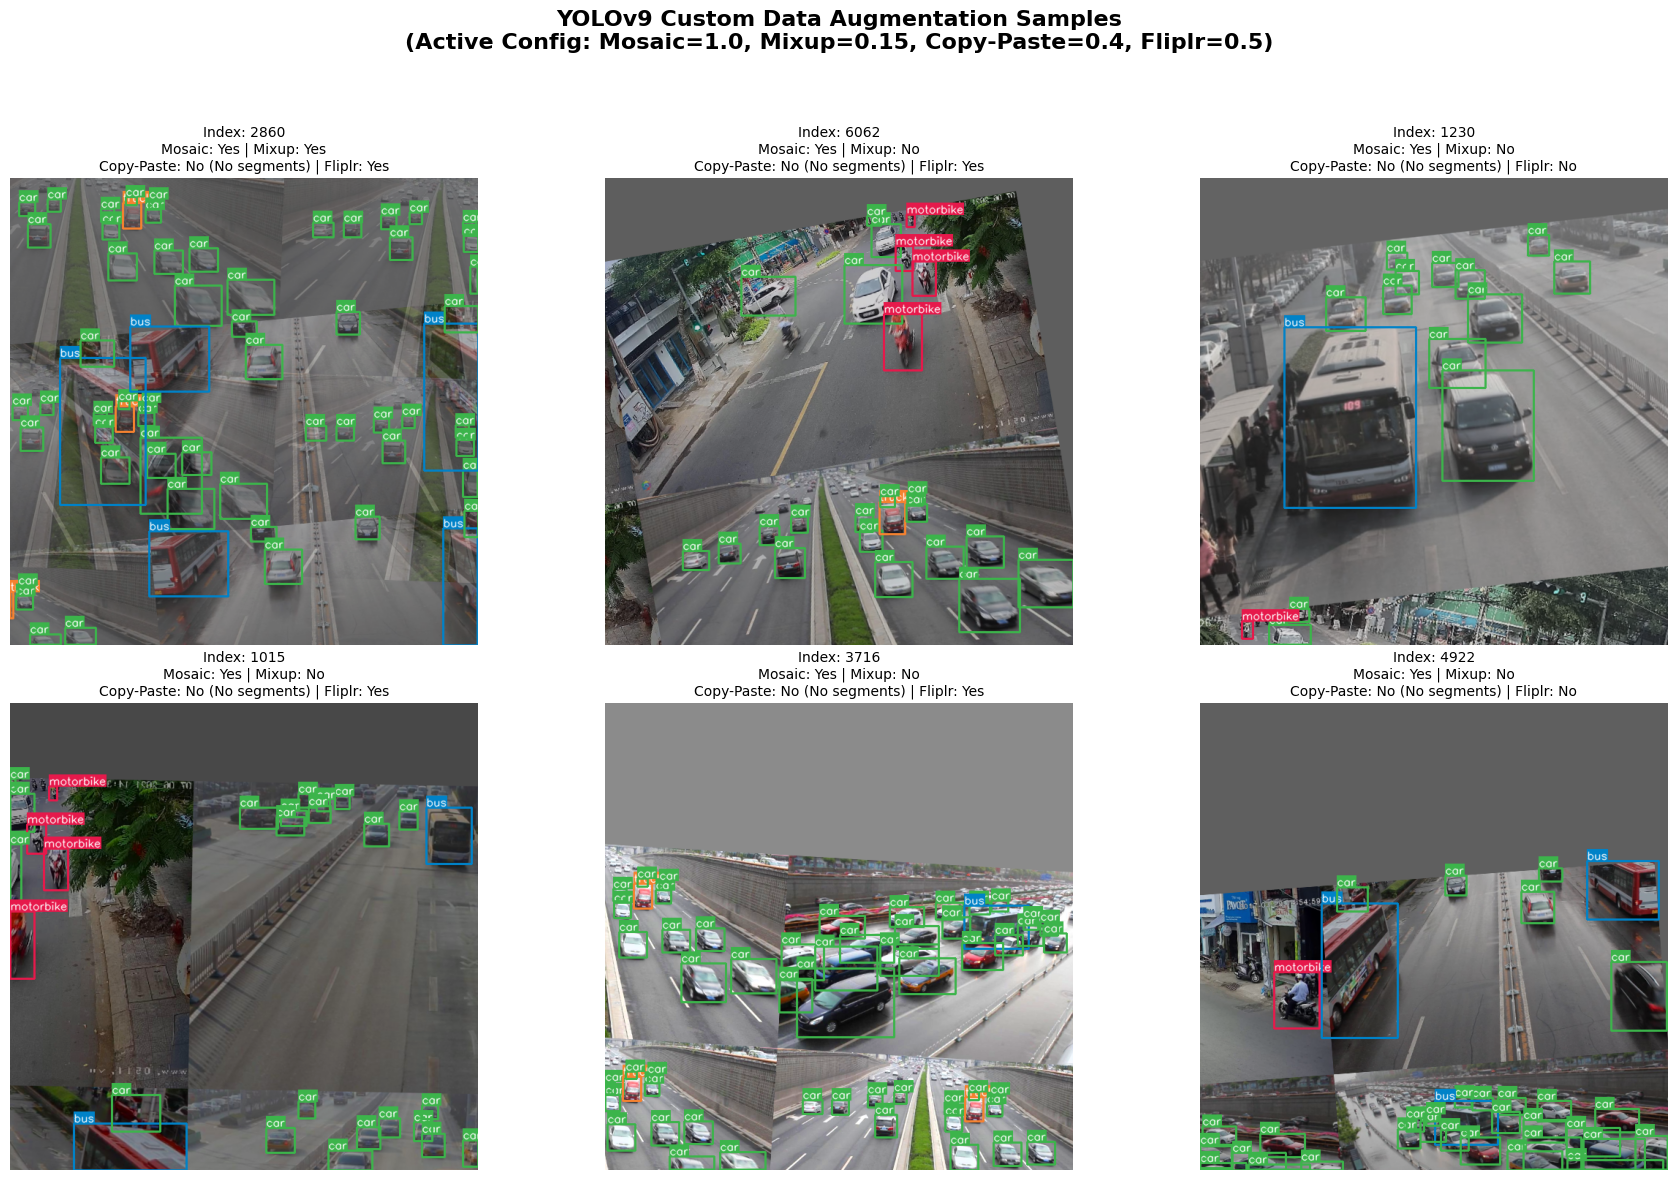

In [5]:
# Plot 6 random augmented samples in a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

np.random.seed()
indices = np.random.choice(len(dataset), size=6, replace=False)

for i, idx in enumerate(indices):
    sample = dataset[idx]
    
    # Transpose image dimensions from CHW (PyTorch) to HWC (OpenCV/Matplotlib)
    img = sample['img'].permute(1, 2, 0).numpy()
    bboxes = sample['bboxes']
    cls_ids = sample['cls']
    
    # Draw boxes & labels
    annotated_img = draw_annotations(img, bboxes, cls_ids)
    
    # Detect specific augmentations applied to this image
    mixup_applied = "Yes" if sample.get("mixup_applied", False) else "No"
    fliplr_applied = "Yes" if sample.get("flip_horizontal_applied", False) else "No"
    
    axes[i].imshow(annotated_img)
    axes[i].set_title(f"Index: {idx}\nMosaic: Yes | Mixup: {mixup_applied}\nCopy-Paste: No (No segments) | Fliplr: {fliplr_applied}", fontsize=10)
    axes[i].axis("off")

fig.suptitle("YOLOv9 Custom Data Augmentation Samples\n(Active Config: Mosaic=1.0, Mixup=0.15, Copy-Paste=0.4, Fliplr=0.5)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()